In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import string
import re

In [2]:
data=pd.read_csv("mental_health_combined_test.csv")
data

,text,status
0,i don't understand whats wrong with me. i don'...,Anxiety
1,usually when i have anxiety just chatting with...,Anxiety
2,"well, i've had anxiety and panic syndrome for ...",Anxiety
3,"for the most minimal of things, like standing ...",Anxiety
4,i stay away from family and live with my roomm...,Anxiety
...,...,...
987,Someone jumped off my building todayI wonder w...,Suicidal
988,helpp??? took 2800mg ibuprofen &amp; 1800mg as...,Suicidal
989,I flunked all my exams am gonna suicideAm goin...,Suicidal
990,I've Got A Serious ProblemI am considering tak...,Suicidal


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 992 entries, 0 to 991
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    992 non-null    object
 1   status  992 non-null    object
dtypes: object(2)
memory usage: 15.6+ KB


In [6]:
data.describe()

,text,status
count,992,992
unique,992,4
top,all I can think about is SuicideI can’t feel a...,Anxiety
freq,1,248


In [7]:
data.isnull().sum()

text      0
status    0
dtype: int64

In [10]:
#check value counts
a=["status"]
for i in a:
    print("coulmn:",i)
    print(data[i].value_counts())
    print("_____________________")
          

coulmn: status
status
Anxiety       248
Depression    248
Normal        248
Suicidal      248
Name: count, dtype: int64
_____________________


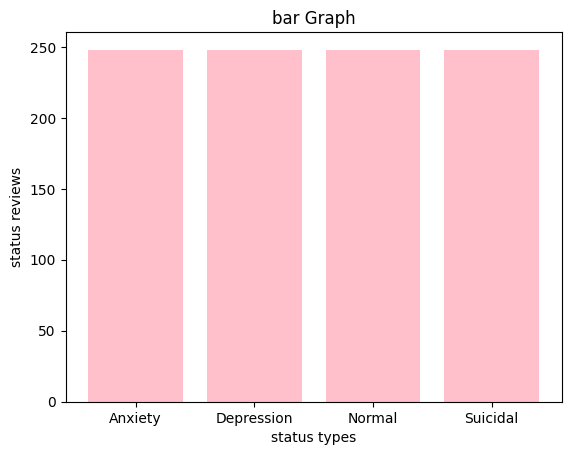

In [11]:
#visualizations
a=data['status'].value_counts()
m=a.index

n=a.values

plt.bar(m,n,color='pink')
plt.title("bar Graph")
plt.xlabel("status types")
plt.ylabel("status reviews")
plt.show()

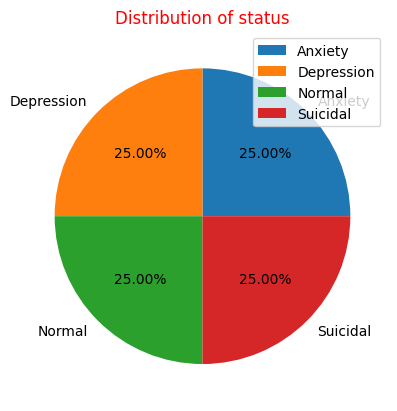

In [12]:
#patient with different worktype---pie chart
x=data['status'].value_counts()
a=x.index
b=x.values
plt.title("Distribution of status",color='r')
plt.pie(b,labels=a,autopct="%1.2f%%")
plt.legend(a)
plt.show()

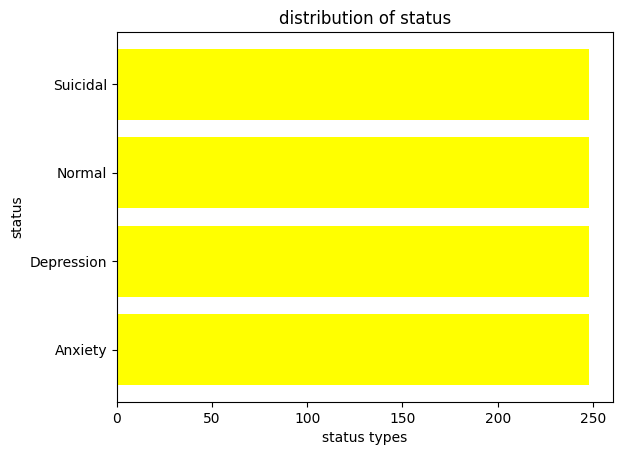

In [13]:
#visualizations
a=data['status'].value_counts()
m=a.index

n=a.values

plt.barh(m,n,color='yellow')
plt.title("distribution of status")
plt.xlabel("status types")
plt.ylabel("status")
plt.show()

In [14]:
#encoding---label column

data['status']=data['status'].map({'Anxiety':0,'Depression':1,'Normal':2,'Suicidal':3})

#CHECK IF CONVERSION WORKED
data['status'].value_counts()

status
0    248
1    248
2    248
3    248
Name: count, dtype: int64

In [15]:
#rename column
data=data.rename(columns={'text_':"text"})
data.columns

Index(['text', 'status'], dtype='object')

In [16]:
#NLP steps for text column
#step1: Lowercase all review text
data['text_lower']=data['text'].astype(str).str.lower()
data[['text','text_lower']].head()

,text,text_lower
0,i don't understand whats wrong with me. i don'...,i don't understand whats wrong with me. i don'...
1,usually when i have anxiety just chatting with...,usually when i have anxiety just chatting with...
2,"well, i've had anxiety and panic syndrome for ...","well, i've had anxiety and panic syndrome for ..."
3,"for the most minimal of things, like standing ...","for the most minimal of things, like standing ..."
4,i stay away from family and live with my roomm...,i stay away from family and live with my roomm...


In [17]:
#step2: REmove punctuation and special characters
def remove_punctuation(text):
    return re.sub(f"[{re.escape(string.punctuation)}]","",text)

data['text_no_punct']=data['text_lower'].apply(remove_punctuation)
data[['text_lower','text_no_punct']].head()

,text_lower,text_no_punct
0,i don't understand whats wrong with me. i don'...,i dont understand whats wrong with me i dont k...
1,usually when i have anxiety just chatting with...,usually when i have anxiety just chatting with...
2,"well, i've had anxiety and panic syndrome for ...",well ive had anxiety and panic syndrome for a ...
3,"for the most minimal of things, like standing ...",for the most minimal of things like standing i...
4,i stay away from family and live with my roomm...,i stay away from family and live with my roomm...


In [18]:
#step3
import nltk
nltk.download('punct')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

#step3:tokenie the cleaned text
data['tokens']=data['text_no_punct'].apply(word_tokenize)
data[['text_no_punct','tokens']].head()

[nltk_data] Error loading punct: Package 'punct' not found in index
[nltk_data] Downloading package punkt_tab to C:\Users\soniya
[nltk_data]     s\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,text_no_punct,tokens
0,i dont understand whats wrong with me i dont k...,"[i, dont, understand, whats, wrong, with, me, ..."
1,usually when i have anxiety just chatting with...,"[usually, when, i, have, anxiety, just, chatti..."
2,well ive had anxiety and panic syndrome for a ...,"[well, ive, had, anxiety, and, panic, syndrome..."
3,for the most minimal of things like standing i...,"[for, the, most, minimal, of, things, like, st..."
4,i stay away from family and live with my roomm...,"[i, stay, away, from, family, and, live, with,..."


In [19]:
#step4
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words=set(stopwords.words('english'))
print(stop_words)

{'re', "he's", "it'd", 'off', 'don', "they'd", 'will', 'just', "we've", 'other', 'ain', "he'll", "aren't", 'himself', 'some', 'than', 'when', "weren't", 'him', "i'd", "she's", 'doesn', 'only', 'about', 'on', 'am', 'few', "i'm", 'which', 'with', "we'll", "he'd", 'll', 'too', 'were', 'but', 'mightn', 'ours', "mustn't", 'she', 'all', 'out', "it'll", 'not', 'you', 'against', 'shan', 'should', 'they', 'themselves', 'under', 'didn', 'does', "wouldn't", "she'll", 'hasn', 'being', 'how', 'my', 'd', 'these', 'an', 'and', 'same', 'ma', "won't", 'into', 'did', 'had', 'more', 'hadn', "it's", 'there', 'aren', 'yourselves', 'down', 'm', "we're", 'above', 'needn', 'of', 'ourselves', 'mustn', 'most', "should've", 'the', 'while', 'his', 'i', 'before', 'your', 'a', "doesn't", 'once', 'both', 'each', 'this', 'weren', 'those', 'have', 'wasn', "shan't", 'haven', 'that', 'are', "that'll", 'o', 'was', 'what', 'we', 'hers', "isn't", "they're", "you're", 'who', 'me', 'her', 'it', 'own', 'because', "i'll", 'won

[nltk_data] Downloading package stopwords to C:\Users\soniya
[nltk_data]     s\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
#step4
data['tokens_no_stopwords']=data['tokens'].apply(lambda tokens:[word for word in tokens if word not in stop_words])
data[['tokens','tokens_no_stopwords']]

,tokens,tokens_no_stopwords
0,"[i, dont, understand, whats, wrong, with, me, ...","[dont, understand, whats, wrong, dont, know, f..."
1,"[usually, when, i, have, anxiety, just, chatti...","[usually, anxiety, chatting, someone, someone,..."
2,"[well, ive, had, anxiety, and, panic, syndrome...","[well, ive, anxiety, panic, syndrome, years, s..."
3,"[for, the, most, minimal, of, things, like, st...","[minimal, things, like, standing, someones, wa..."
4,"[i, stay, away, from, family, and, live, with,...","[stay, away, family, live, roommate, literally..."
...,...,...
987,"[someone, jumped, off, my, building, todayi, w...","[someone, jumped, building, todayi, wonder, like]"
988,"[helpp, took, 2800mg, ibuprofen, amp, 1800mg, ...","[helpp, took, 2800mg, ibuprofen, amp, 1800mg, ..."
989,"[i, flunked, all, my, exams, am, gon, na, suic...","[flunked, exams, gon, na, suicideam, going, ba..."
990,"[ive, got, a, serious, problemi, am, consideri...","[ive, got, serious, problemi, considering, tak..."


In [21]:
#step 5:lemmatization
nltk.download("wordnet")
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer

lemmatizer=WordNetLemmatizer()

#STEP5: LEMMATIZE EAC TOKEN
data['lemmatized_tokens']=data['tokens_no_stopwords'].apply(lambda tokens:[lemmatizer.lemmatize(word) for word in tokens])
data[['tokens_no_stopwords','lemmatized_tokens']].head()

[nltk_data] Downloading package wordnet to C:\Users\soniya
[nltk_data]     s\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\soniya
[nltk_data]     s\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,tokens_no_stopwords,lemmatized_tokens
0,"[dont, understand, whats, wrong, dont, know, f...","[dont, understand, whats, wrong, dont, know, f..."
1,"[usually, anxiety, chatting, someone, someone,...","[usually, anxiety, chatting, someone, someone,..."
2,"[well, ive, anxiety, panic, syndrome, years, s...","[well, ive, anxiety, panic, syndrome, year, st..."
3,"[minimal, things, like, standing, someones, wa...","[minimal, thing, like, standing, someone, way,..."
4,"[stay, away, family, live, roommate, literally...","[stay, away, family, live, roommate, literally..."


In [22]:
#step6:join tokens back into a cleaned string
data['final_cleaned_text']=data['lemmatized_tokens'].apply(lambda tokens:" ".join(tokens))
data[['text','final_cleaned_text']].head()

,text,final_cleaned_text
0,i don't understand whats wrong with me. i don'...,dont understand whats wrong dont know freak so...
1,usually when i have anxiety just chatting with...,usually anxiety chatting someone someone physi...
2,"well, i've had anxiety and panic syndrome for ...",well ive anxiety panic syndrome year started s...
3,"for the most minimal of things, like standing ...",minimal thing like standing someone way moment...
4,i stay away from family and live with my roomm...,stay away family live roommate literally game ...


In [24]:
#step 7
from sklearn.feature_extraction.text import TfidfVectorizer

#create TF-IDF vectorizer object
vectorizer=TfidfVectorizer(max_features=5000)#you can adjust

#fit and transform the cleaned text
x=vectorizer.fit_transform(data['final_cleaned_text'])

#target label
y=data['status']

In [25]:
from sklearn.model_selection import train_test_split
#split data:80% training,20% testing

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [26]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(793, 5000)
(199, 5000)
(793,)
(199,)


In [27]:
#Model training
#Logistic regression
#1.import algorithm
from sklearn.linear_model import LogisticRegression

#2.Object for class
#model
lr=LogisticRegression()
#model traning
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [28]:
lr_result=lr.predict(x_test)
print(lr_result)

[0 1 1 1 1 2 1 0 0 2 1 0 1 3 0 3 1 2 0 3 0 2 2 2 2 1 3 2 1 2 3 1 2 2 2 2 3
 2 2 2 1 0 0 2 0 0 2 1 2 2 0 1 3 2 3 3 2 1 3 0 1 1 3 0 3 0 1 3 3 1 3 0 2 1
 0 3 3 3 2 3 1 2 0 3 0 2 3 2 3 0 3 3 1 2 2 3 0 2 3 2 3 1 2 2 1 0 3 1 1 1 2
 0 1 2 2 2 2 3 3 3 0 0 1 1 0 2 2 2 2 1 1 1 2 0 0 2 2 3 3 1 1 1 0 3 3 3 2 2
 3 1 3 0 2 3 3 0 2 2 2 0 0 1 3 0 3 2 3 0 3 0 2 3 3 2 2 2 3 3 3 0 0 3 1 3 2
 0 2 1 2 0 0 2 2 2 2 3 1 2 3]


In [29]:
#model evaluation

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

score_lr=accuracy_score(y_test,lr_result)
print("Accuracy score for lr model:",score_lr)

Accuracy score for lr model: 0.6432160804020101


In [30]:
#classification report
report=classification_report(y_test,lr_result)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.70      0.73        44
           1       0.54      0.45      0.49        49
           2       0.67      0.84      0.75        51
           3       0.60      0.58      0.59        55

    accuracy                           0.64       199
   macro avg       0.64      0.64      0.64       199
weighted avg       0.64      0.64      0.64       199



[[31  4  4  5]
 [ 5 22  8 14]
 [ 3  3 43  2]
 [ 2 12  9 32]]


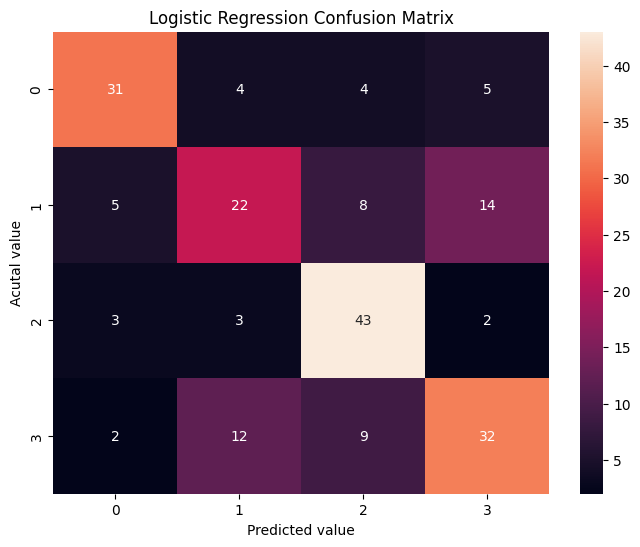

In [31]:
#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(y_test,lr_result)
print(cm)

plt.figure(figsize=(8,6),dpi=(100))
plt.title("Logistic Regression Confusion Matrix")

sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted value")
plt.ylabel("Acutal value")
plt.show()

In [32]:
#decison tree classifier
from sklearn.tree import DecisionTreeClassifier
#model building
dt=DecisionTreeClassifier()
#model traning
dt.fit(x_train,y_train)
#model testing
dt_result=dt.predict(x_test)
print(dt_result)

[0 2 3 2 1 2 1 0 0 3 1 3 1 0 2 3 3 2 3 3 0 2 2 2 1 3 0 3 1 1 1 2 2 2 2 2 2
 2 3 3 3 1 0 2 2 1 0 1 3 0 2 3 2 2 3 1 2 1 0 0 1 1 3 1 3 0 1 1 0 1 1 0 1 1
 0 1 2 3 1 3 3 2 0 3 0 2 3 3 1 1 1 3 2 2 0 0 0 2 2 1 3 1 0 3 3 0 3 1 1 1 2
 3 3 2 2 2 1 1 3 3 0 0 1 0 0 0 0 2 0 0 3 1 2 0 1 1 0 1 3 0 2 3 0 3 1 1 2 2
 1 1 1 0 1 1 3 0 2 2 2 0 1 1 3 2 3 1 3 0 3 1 3 1 3 0 2 2 1 1 0 0 0 3 3 3 2
 0 2 3 2 0 0 2 3 1 2 3 1 2 3]


In [33]:
#model evaluation

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

score_dt=accuracy_score(y_test,dt_result)
print("Accuracy score for dt model:",score_dt)

#classification report
report=classification_report(y_test,dt_result)
print("Classification Report:\n")
print(report)

Accuracy score for dt model: 0.5326633165829145
Classification Report:

              precision    recall  f1-score   support

           0       0.60      0.61      0.61        44
           1       0.45      0.51      0.48        49
           2       0.57      0.55      0.56        51
           3       0.52      0.47      0.50        55

    accuracy                           0.53       199
   macro avg       0.54      0.54      0.54       199
weighted avg       0.53      0.53      0.53       199



[[27 10  4  3]
 [ 3 25  9 12]
 [ 8  6 28  9]
 [ 7 14  8 26]]


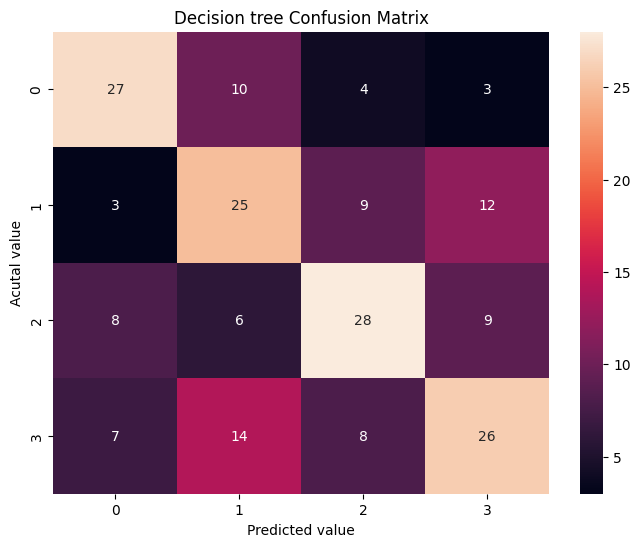

In [34]:
#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(y_test,dt_result)
print(cm)

plt.figure(figsize=(8,6),dpi=(100))
plt.title("Decision tree Confusion Matrix")

sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted value")
plt.ylabel("Acutal value")
plt.show()

In [35]:
#random forest classifier
from sklearn.ensemble import RandomForestClassifier
#model building
rf=RandomForestClassifier()

In [36]:
#model traning
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
#model testing
rf_result=rf.predict(x_test)
print(rf_result)

[0 1 1 1 1 2 2 0 0 2 1 1 1 0 2 3 1 2 0 3 0 2 2 2 2 1 3 2 1 3 1 2 2 2 2 2 3
 2 2 3 1 0 0 2 0 3 2 3 2 2 0 1 3 2 3 1 2 1 0 0 1 1 1 1 1 0 1 3 3 1 1 0 2 1
 0 3 2 3 0 3 1 2 0 3 0 2 3 2 2 0 3 3 1 2 2 0 0 2 2 2 3 3 2 2 1 0 1 1 3 1 2
 0 3 2 2 2 3 3 3 3 0 0 3 2 0 2 2 2 2 1 3 1 2 0 3 2 2 3 3 1 2 1 0 3 3 2 2 2
 3 2 3 0 1 3 1 0 2 2 2 0 1 1 1 0 3 2 3 0 3 1 2 3 3 2 2 2 3 3 3 0 0 3 3 3 2
 0 2 3 2 0 0 2 2 2 2 1 1 2 3]


In [38]:
#model evaluation

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

score_rf=accuracy_score(y_test,rf_result)
print("Accuracy score for dt model:",score_rf)

#classification report
report=classification_report(y_test,rf_result)
print("Classification Report:\n")
print(report)

Accuracy score for dt model: 0.6381909547738693
Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.75      0.80        44
           1       0.52      0.45      0.48        49
           2       0.62      0.84      0.72        51
           3       0.58      0.53      0.55        55

    accuracy                           0.64       199
   macro avg       0.65      0.64      0.64       199
weighted avg       0.64      0.64      0.63       199



[[33  5  2  4]
 [ 1 22 12 14]
 [ 4  1 43  3]
 [ 0 14 12 29]]


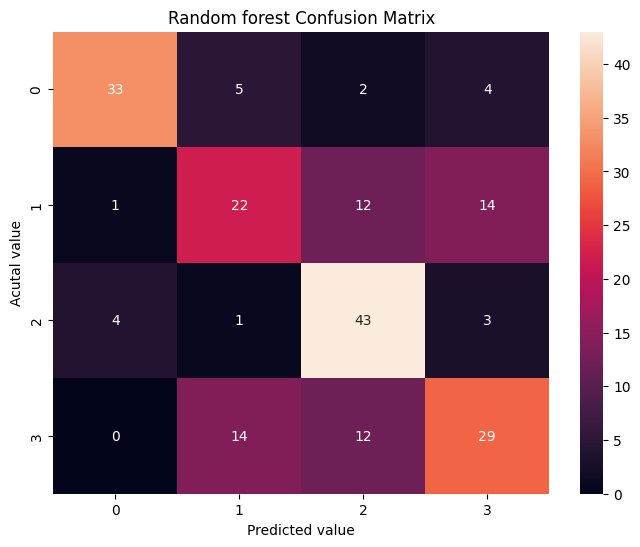

In [40]:
#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(y_test,rf_result)
print(cm)

plt.figure(figsize=(8,6),dpi=(100))
plt.title("Random forest Confusion Matrix")

sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted value")
plt.ylabel("Acutal value")
plt.show()

In [41]:
#svm--Support Vector Machine
#Support Vector Classifer(SVC)
from sklearn.svm import SVC


In [42]:
#model building
svc=SVC()

In [43]:
#model traning
svc.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [44]:
#model testing
svc_result=svc.predict(x_test)
print(svc_result)

[0 1 1 1 1 2 1 0 0 2 1 0 1 3 1 3 1 2 0 3 0 2 2 2 2 1 3 2 1 2 3 2 2 2 2 2 3
 2 2 2 1 0 0 2 0 0 2 1 2 2 0 1 3 2 3 3 2 1 3 0 1 1 3 1 3 0 1 3 3 1 3 0 2 1
 0 3 3 3 2 3 1 2 0 3 0 2 3 2 3 0 3 2 1 2 2 3 0 2 1 2 3 1 2 2 1 0 3 1 1 1 2
 0 1 2 2 2 2 3 3 3 0 0 1 1 0 2 2 2 2 1 3 1 2 0 0 2 2 3 3 1 1 1 0 3 3 1 2 2
 3 1 3 0 2 3 3 0 2 2 2 0 0 1 3 0 3 2 3 0 3 1 2 3 3 2 2 2 3 1 3 0 0 3 1 3 2
 0 2 1 2 0 0 2 2 2 2 3 1 2 3]


In [45]:
#model evaluation

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

score_svc=accuracy_score(y_test,svc_result)
print("Accuracy score for svc model:",score_svc)

#classification report
report=classification_report(y_test,svc_result)
print("Classification Report:\n")
print(report)

Accuracy score for svc model: 0.6482412060301508
Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.70      0.76        44
           1       0.53      0.49      0.51        49
           2       0.67      0.86      0.75        51
           3       0.60      0.55      0.57        55

    accuracy                           0.65       199
   macro avg       0.65      0.65      0.65       199
weighted avg       0.65      0.65      0.64       199



[[31  5  4  4]
 [ 3 24  8 14]
 [ 3  2 44  2]
 [ 1 14 10 30]]


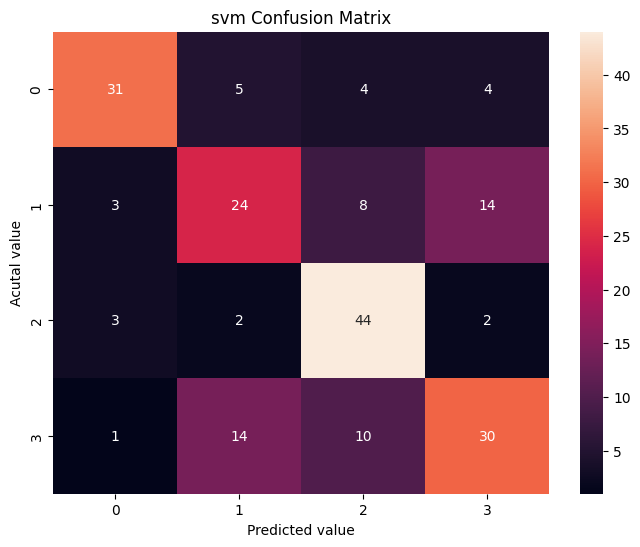

In [46]:
#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(y_test,svc_result)
print(cm)

plt.figure(figsize=(8,6),dpi=(100))
plt.title("svm Confusion Matrix")

sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted value")
plt.ylabel("Acutal value")
plt.show()

In [47]:
#XGBoost Classifier
from xgboost import XGBClassifier

xg=XGBClassifier()

In [48]:
#model traning
xg.fit(x_train,y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [49]:
#model testing
xgb_result=xg.predict(x_test)
print(xgb_result)

[0 1 0 1 1 2 0 0 0 2 3 1 0 0 1 3 3 2 1 3 0 2 2 2 2 3 0 3 1 3 3 2 2 2 2 2 3
 2 2 3 1 0 0 2 0 3 2 1 2 1 2 1 3 0 0 1 2 1 0 0 1 1 3 3 3 0 1 3 3 0 1 0 2 3
 0 3 2 3 3 3 1 2 0 3 0 2 3 2 1 1 1 3 1 2 2 3 0 2 3 2 3 1 2 2 3 0 3 1 3 1 2
 0 3 2 2 2 1 1 3 3 0 0 1 1 0 2 0 3 3 1 3 2 2 0 1 3 3 3 3 1 1 1 0 3 3 2 2 2
 1 1 3 0 1 1 3 0 2 2 2 0 3 1 3 2 3 1 3 0 3 1 3 1 3 0 3 2 1 3 3 0 0 3 3 3 2
 0 2 3 2 3 0 2 2 2 2 3 1 2 1]


In [50]:
#model evaluation

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

score_xgb=accuracy_score(y_test,xgb_result)
print("Accuracy score for svc model:",score_xgb)

#classification report
report=classification_report(y_test,xgb_result)
print("Classification Report:\n")
print(report)

Accuracy score for svc model: 0.6331658291457286
Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.70      0.74        44
           1       0.56      0.51      0.53        49
           2       0.70      0.73      0.71        51
           3       0.54      0.60      0.57        55

    accuracy                           0.63       199
   macro avg       0.64      0.64      0.64       199
weighted avg       0.64      0.63      0.63       199



[[31  6  2  5]
 [ 4 25  5 15]
 [ 4  2 37  8]
 [ 1 12  9 33]]


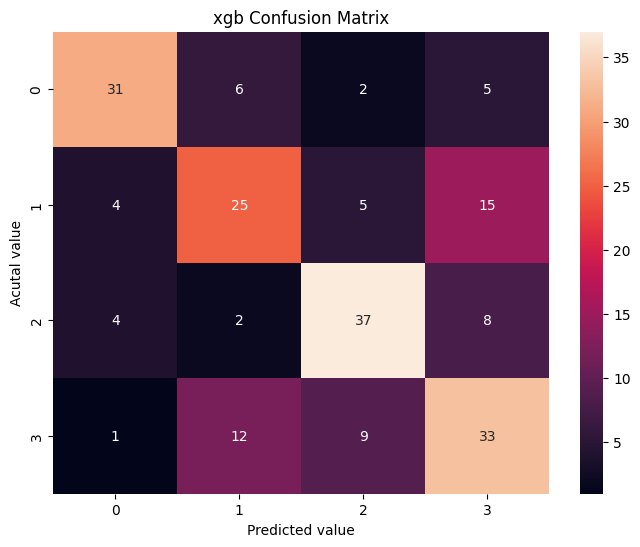

In [51]:
#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(y_test,xgb_result)
print(cm)

plt.figure(figsize=(8,6),dpi=(100))
plt.title("xgb Confusion Matrix")

sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted value")
plt.ylabel("Acutal value")
plt.show()

In [53]:
import joblib

#save model
joblib.dump(svc,'svc_model_mental_health.pkl')

#save coumn structure(imp)
joblib.dump(vectorizer,'tfidf_vectorizer_mental_health.pkl')

print("model saved vector saved successfully")

model saved vector saved successfully


In [55]:
#testing
import joblib
import re
import nltk
import string

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#download(only first time)
#nltk.download('punkt')

#load saved model and vectorizer
svm_model=joblib.load('svc_model_mental_health.pkl')
tfidf_vectorizer=joblib.load('tfidf_vectorizer_mental_health.pkl')

def predict_fake_review_svm(text):
    #step 1: lowercase
    text=text.lower()

    #step 2: remove punctuation
    text=re.sub(f"[{re.escape(string.punctuation)}]","",text)

    #step 3: tokenization
    tokens=word_tokenize(text)

    #step 4: remove stopwords
    stop_words=set(stopwords.words('english'))
    tokens=[word for word in tokens if word not in stop_words]

    #step 5: lemmatization
    lemmatizer=WordNetLemmatizer()
    tokens=[lemmatizer.lemmatize(word) for word in tokens]

    #step 6: join tokens
    clean_text=" ".join(tokens)

    #step 7: vectorize
    x_input=tfidf_vectorizer.transform([clean_text])

    #step 8: predict
    prediction=svm_model.predict(x_input)[0]
    print(prediction)

    return "Anxiety" if prediction==0 else "Depression" if prediction==1 else "Normal" if prediction==2 else "Suicidal"
    

In [56]:
text="i don't understand whats wrong with me. i don"

print("SVM Prediction:",predict_fake_review_svm(text))

2
SVM Prediction: Normal


In [57]:
text="usually when i have anxiety just chatting with"

print("SVM Prediction:",predict_fake_review_svm(text))

0
SVM Prediction: Anxiety


In [58]:
text="i stay away from family and live with my roomm"

print("SVM Prediction:",predict_fake_review_svm(text))

2
SVM Prediction: Normal


In [60]:
data.sample(5)

,text,status,text_lower,text_no_punct,tokens,tokens_no_stopwords,lemmatized_tokens,final_cleaned_text
770,I've decidedThat within a year I'll either get...,3,i've decidedthat within a year i'll either get...,ive decidedthat within a year ill either get r...,"[ive, decidedthat, within, a, year, ill, eithe...","[ive, decidedthat, within, year, ill, either, ...","[ive, decidedthat, within, year, ill, either, ...",ive decidedthat within year ill either get rid...
96,i'm a 21 year old female brit who voted remain...,0,i'm a 21 year old female brit who voted remain...,im a 21 year old female brit who voted remain ...,"[im, a, 21, year, old, female, brit, who, vote...","[im, 21, year, old, female, brit, voted, remai...","[im, 21, year, old, female, brit, voted, remai...",im 21 year old female brit voted remain refere...
951,if i had a shotgun id hav edone it alreadytoo ...,3,if i had a shotgun id hav edone it alreadytoo ...,if i had a shotgun id hav edone it alreadytoo ...,"[if, i, had, a, shotgun, id, hav, edone, it, a...","[shotgun, id, hav, edone, alreadytoo, scared, ...","[shotgun, id, hav, edone, alreadytoo, scared, ...",shotgun id hav edone alreadytoo scared jump af...
82,i am 17 years old and i will be needing to get...,0,i am 17 years old and i will be needing to get...,i am 17 years old and i will be needing to get...,"[i, am, 17, years, old, and, i, will, be, need...","[17, years, old, needing, get, job, summer, mu...","[17, year, old, needing, get, job, summer, muc...",17 year old needing get job summer much social...
817,"If only i had a gunHello everyone, i am about ...",3,"if only i had a gunhello everyone, i am about ...",if only i had a gunhello everyone i am about t...,"[if, only, i, had, a, gunhello, everyone, i, a...","[gunhello, everyone, write, saying, head, much...","[gunhello, everyone, write, saying, head, much...",gunhello everyone write saying head much time ...
